# Overview 

This notebook is for catalog-paper sample description figures, not Hα metric analysis.

Planned contents:

- sky distribution of Hα sample
  - Virgo filament / cluster context
- sfr - mstar plot
- histogram comparing halpha vs parent catalog in terms of:
  - distance
  - stellar mass
  - SFR
  - morphology/type
  - environment class
- filters
- 


In [3]:
import os
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
import glob
import warnings
warnings.filterwarnings('ignore')

homedir = os.getenv("HOME")
plotdir = homedir + "/research/Virgo/hapypost/plots/"

# Sky Plot

table directory = /Users/rfinn/research/Virgo/tables-north/v2/
CO galaxies with no Halpha
VFID1899
VFID3540
VFID5835
VFID6025


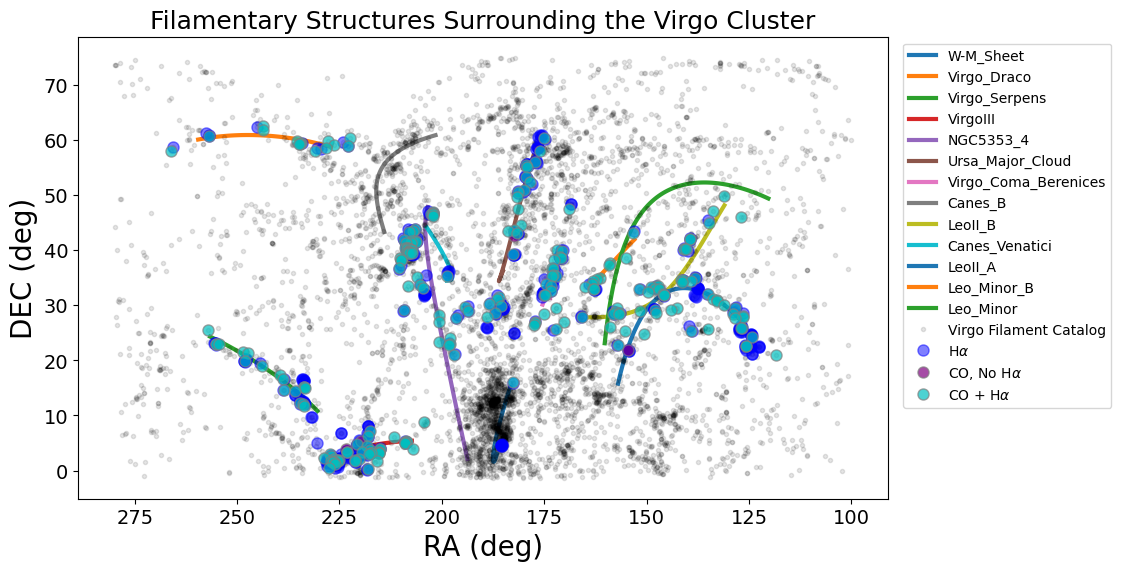

In [26]:
%run ../scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_halpha_sky_positions(v, args.plotdir)
plt.show()

### working on resolving missing CO galaxies - they were observed!

- most of these are missing due to a problem in `get_cutouts` and the `_weight_ok` function which was too stringent.

| VFID | Explanation | 
| ---|---|
|VFID1899 | Star contamination |
| VFID3540 | Star contamination |
| VFID5835 | not in the latest cutout list; was in pre2025 data VF-219.948+05.394-INT-20190530-p019; the new coadd is there, but it seems like a large number of pixels are saturated, like I saw before with the centers of stars... |
| VFID6025 | Star contamination |

In [3]:
np.sum(v.main["COflag"] & v.main['HAobsflag'])

242

In [4]:
flag = v.main["COflag"] & v.main['HAobsflag'] & ~v.halpha["HAPY_HAS_OBS"] 

In [5]:
v.main['VFID'][flag]

VFID1899
VFID3540
VFID5835
VFID6025


In [17]:
print(v.main['NEDname'][5835])

NGC 5701


# SFR-Mstar Sample Overview

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


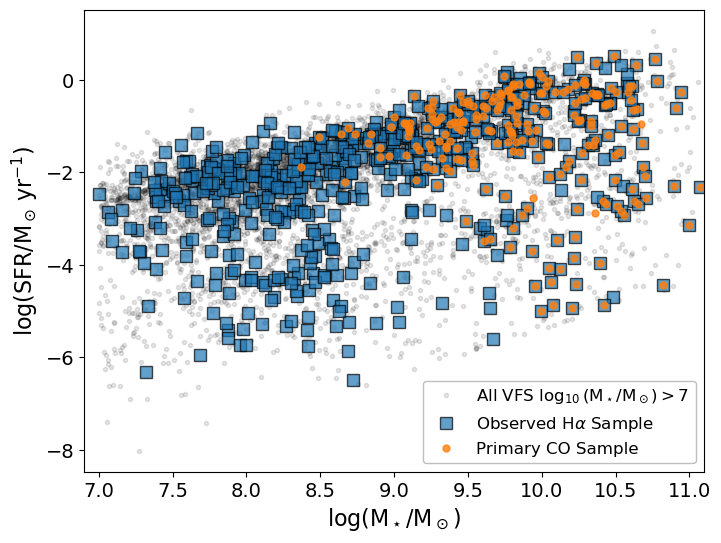

In [9]:
%run ~/github/hapypost/scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_sfr_mstar_sample(v, args.plotdir)
plt.show()

# Redshift Distribution

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


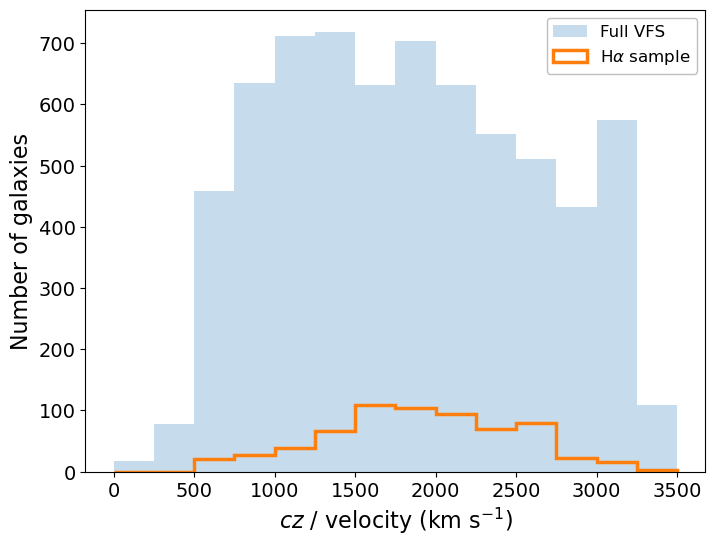

In [10]:
%run ~/github/hapypost/scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_redshift_distribution(v, args.plotdir)
plt.show()

# Environment Distribution

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


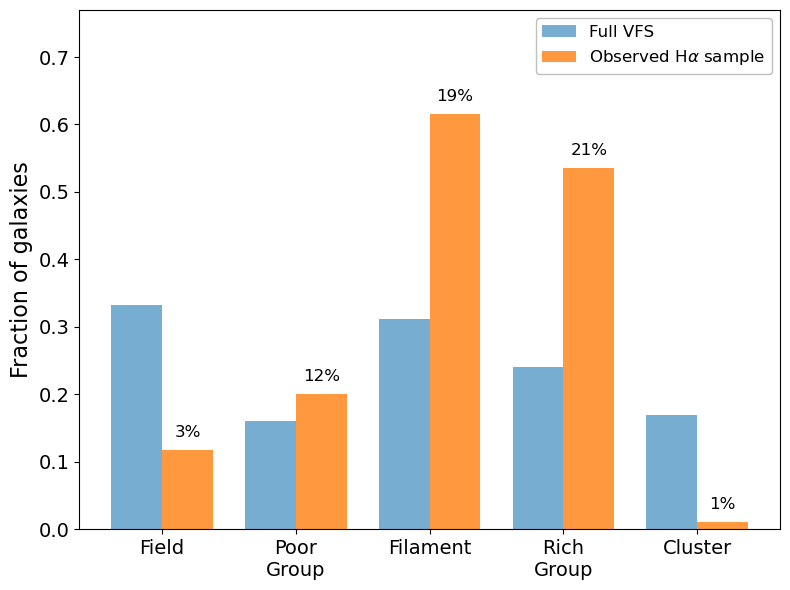

In [22]:
%run ~/github/hapypost/scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_environment_distribution(v, args.plotdir, show=True)
#plt.show()

# Filters

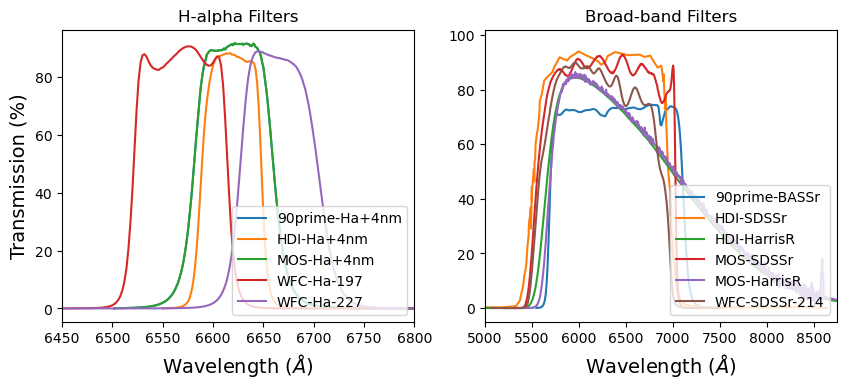

In [28]:
# redoing after standardizing filters


filter_dir = homedir+'/research/Halpha_filters/fits_versions/'
hafilters = glob.glob(filter_dir+'*Ha*.fits')
plt.figure(figsize=(10,4))
plt.subplots_adjust(bottom=.15)
xlab = "Wavelength ($\AA$)"
ylab = "Transmission (%)"

# plot halpha filters
hafilters = ['BOK90prime-Ha+4nm.fits',
             'HDI-Ha+4nm.fits',
             'MOS-Ha+4nm.fits',
             'WFC-Ha-197.fits',
             'WFC-Ha-227.fits']

rfilters = ['BOK90prime-BASSr.fits',
             'HDI-SDSSr.fits',
             'HDI-HarrisR.fits',
             'MOS-SDSSr.fits',
             'MOS-HarrisR.fits',
             'WFC-SDSSr-214.fits',
            ]


plt.subplot(1,2,1)
for i,f in enumerate(hafilters):
    tab = Table.read(os.path.join(filter_dir,f))
    plt.plot(tab['wavelength'],tab['transmission'],label=os.path.basename(f).replace('.fits','').replace('BOK',''))
    #print(halabels[i],f"{integrate_filter(wav,T):.2f}")
plt.xlabel(xlab,fontsize=14)
plt.ylabel(ylab,fontsize=14)
plt.title("H-alpha Filters")
plt.xlim(6450,6800)
#plt.ylim(-5,102)
plt.legend(loc='lower right',fontsize=10)


plt.subplot(1,2,2)
# plot halpha filters
for i,f in enumerate(rfilters):
    tab = Table.read(os.path.join(filter_dir,f))
    plt.plot(tab['wavelength'],tab['transmission'],label=os.path.basename(f).replace('.fits','').replace('BOK',''))
    #print(rlabels[i],f"{integrate_filter(wav,T):.2f}")
plt.legend(loc='lower right',fontsize=10)
plt.xlabel(xlab,fontsize=14)
#plt.ylabel(ylab,fontsize=16)
plt.xlim(5000,8750)
plt.ylim(-5,102)
plt.title("Broad-band Filters")

# plot wavelength of halpha
lambda0 = 6563
vr_virgo = 2000
#plt.axvline(x=6625)
plt.savefig(homedir+'/research/Virgo/hapypost/plots/filter_traces_v2.png',dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.savefig(homedir+'/research/Virgo/hapypost/plots/filter_traces_v2.pdf',dpi=300, bbox_inches="tight", pad_inches=0.02)


tabledir =  /Users/rfinn/research/Virgo/tables-north/v2/


KeyError: 'M26'

mean(med) diff b/w R and Halpha PSF = 0.02(0.02) +/- 0.17
H FWHM - R FWHM = 0.02 +/- 0.17


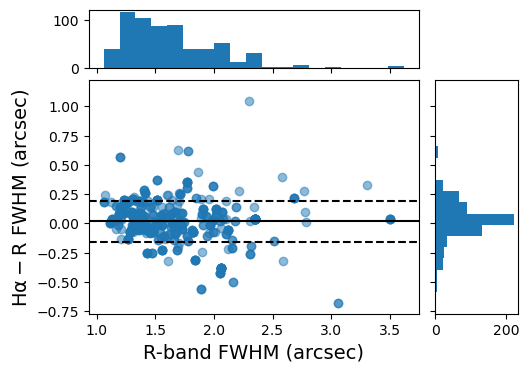

In [29]:
%run ~/github/havirgo/python/ha-paper1.py
h.plot_fwhm_r_h()

In [23]:
9.25E-05 * 3600


0.333

# VESTIGE Inspired Plots

- Morgan+2024

In [24]:
# plot R75_kpc vs stellar mass, then H75_kpc vs stellar mass

# or H75 vs R75, color coded by logMstar

table directory = /Users/rfinn/research/Virgo/tables-north/v2/
number in selection 296/6780


<Figure size 640x480 with 0 Axes>

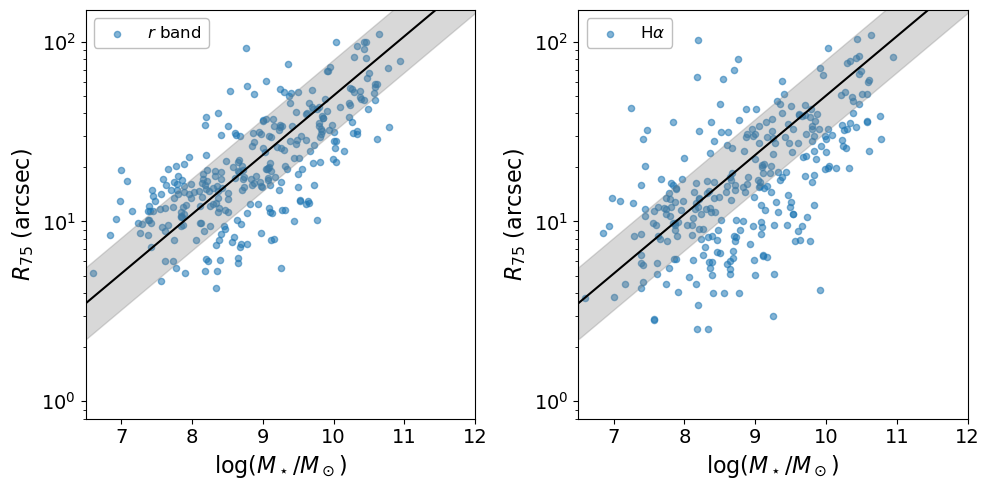

In [40]:

%run ~/github/hapypost/scripts/plot_morphology.py
catflag = v.halpha['CATALOG_USE'] == 'CLEAN'
incflag = v.halpha['ELLIP_BA'] > 0.3
ssfrflag = np.log10(v.cigale['bayes.sfh.sfr']/v.cigale['bayes.stellar.m_star']) > -11.5
maskflag = v.halpha['MASKFRAC_GUESS_ELLIPSE'] < 0.2
hasnr = v.halpha['H_TOT_FLUX_CGS']/v.halpha['H_TOT_FLUX_CGS_ERR'] > 10
selection = catflag & incflag & ssfrflag & maskflag & hasnr

print(f"number in selection {np.sum(selection)}/{len(selection)}")

plot_size_mass_relation(v, args.plotdir, selection=selection, show=True)



In [32]:
# calzetting 2012 + Chabrier IMF

    plot_size_ratio_mass(v, args.plotdir, selection=None)
    plot_gini_comparison(v, args.plotdir, selection=None)
    plot_delta_gini_m20(v, args.plotdir, selection=None)


In [34]:
%

NameError: name 'logMstar' is not defined

In [35]:
v.cigale.colnames

['id',
 'bayes.agn.fracAGN',
 'bayes.agn.fracAGN_err',
 'bayes.attenuation.Av_ISM',
 'bayes.attenuation.Av_ISM_err',
 'bayes.sfh.age',
 'bayes.sfh.age_err',
 'bayes.sfh.burst_age',
 'bayes.sfh.burst_age_err',
 'bayes.sfh.f_burst',
 'bayes.sfh.f_burst_err',
 'bayes.sfh.tau_burst',
 'bayes.sfh.tau_burst_err',
 'bayes.sfh.tau_main',
 'bayes.sfh.tau_main_err',
 'bayes.stellar.metallicity',
 'bayes.stellar.metallicity_err',
 'bayes.dust.mass',
 'bayes.dust.mass_err',
 'bayes.sfh.sfr',
 'bayes.sfh.sfr_err',
 'bayes.stellar.m_star',
 'bayes.stellar.m_star_err',
 'bayes.BASS-g',
 'bayes.BASS-g_err',
 'bayes.BASS-r',
 'bayes.BASS-r_err',
 'bayes.FUV',
 'bayes.FUV_err',
 'bayes.NUV',
 'bayes.NUV_err',
 'bayes.WISE1',
 'bayes.WISE1_err',
 'bayes.WISE2',
 'bayes.WISE2_err',
 'bayes.WISE3',
 'bayes.WISE3_err',
 'bayes.WISE4',
 'bayes.WISE4_err',
 'bayes.decamDR1-g',
 'bayes.decamDR1-g_err',
 'bayes.decamDR1-r',
 'bayes.decamDR1-r_err',
 'bayes.decamDR1-z',
 'bayes.decamDR1-z_err',
 'best.chi_square